# 04 - Model Training and Prediction

**Objective:** Train classification models on breast cancer data and evaluate performance.

**Steps:**
1. Load engineered data and split into train/test
2. Scale features (for distance-based models)
3. Train multiple classification models
4. Evaluate and compare models
5. Log experiments with MLflow
6. Save models for later use

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import joblib

print("Libraries imported successfully")

Libraries imported successfully


## Data Loading

In [2]:
PROCESSED_DIR = Path("../data/processed")
CORRUPED_DIR = PROCESSED_DIR / "corrupted"


if (PROCESSED_DIR / "engineered_data.csv").exists():
    df = pd.read_csv(PROCESSED_DIR / "engineered_data.csv")
    print("Loaded engineered_data.csv")
else:
    df = pd.read_csv(PROCESSED_DIR / "clean_data.csv")
    print("Loaded clean_data.csv")


X = df.drop(columns=["Diagnosis"])
y = df["Diagnosis"]
print(f"Features: {X.shape}, Target: {y.shape}")
print(y.value_counts())

Loaded engineered_data.csv
Features: (569, 34), Target: (569,)
Diagnosis
0    357
1    212
Name: count, dtype: int64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class balance:\n{y_train.value_counts(normalize=True)}")

Train: (455, 34), Test: (114, 34)
Train class balance:
Diagnosis
0    0.626374
1    0.373626
Name: proportion, dtype: float64


## Feature Scaling

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Mean after scaling (first 5): {X_train_scaled.mean(axis=0)[:5]}")
print(f"Std after scaling (first 5): {X_train_scaled.std(axis=0)[:5]}")
print(f"All means near zero: {np.allclose(X_train_scaled.mean(axis=0), 0, atol=1e-10)}")

Mean after scaling (first 5): [-1.73731603e-16  3.90408097e-16  4.70441756e-16 -1.17122429e-16
  7.24207019e-16]
Std after scaling (first 5): [1. 1. 1. 1. 1.]
All means near zero: True


## Model Training

Scikit-learn provides a consistent API for training various models.

Every predictor in scikit-learn has a `fit()` method for training and a `predict()` method for making predictions.

Each model has its own strengths and weaknesses, so we will train multiple models to compare their performance.

In [5]:
# We begin by loading the classifier libraries we will use for training our models.

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [6]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
print(f"LogisticRegression coefficients (first 5): {lr_model.coef_[0][:5]}")

LogisticRegression coefficients (first 5): [0.28140081 0.46713294 0.27347135 0.36858535 0.36569088]


In [7]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print(f"RandomForest feature importances (first 5): {rf_model.feature_importances_[:5]}")

RandomForest feature importances (first 5): [0.03919949 0.01311926 0.03780258 0.03544568 0.00915137]


In [8]:
xgb_model = XGBClassifier(n_estimators=100, eval_metric="logloss", random_state=42)
xgb_model.fit(X_train, y_train)
print(f"XGBoost feature importances (first 5): {xgb_model.feature_importances_[:5]}")

XGBoost feature importances (first 5): [0.         0.01472603 0.00579958 0.03421848 0.00523244]


In [9]:
svc_model = SVC(kernel='rbf', random_state=42)
svc_model.fit(X_train_scaled, y_train)
print(f"SVC support vectors per class: {svc_model.n_support_}")

SVC support vectors per class: [51 56]


In [10]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
print(f"DecisionTree feature importances (first 5): {dt_model.feature_importances_[:5]}")

DecisionTree feature importances (first 5): [0.         0.03068292 0.         0.0236323  0.02071081]


### The Confusion Matrix

The confusion matrix is a table that summarizes the performance of a classification model. It shows the counts of true positives, true negatives, false positives, and false negatives.

|               | Predicted Positive | Predicted Negative |
|---------------|--------------------|--------------------|
| Actual Positive | True Positives (TP) | False Negatives (FN) |
| Actual Negative | False Positives (FP) | True Negatives (TN) |    

in the context of breast cancer classification:
```python
from sklearn.metrics import confusion_matrix

y_true = [1, 0, 1, 1, 0, 1]  # Actual labels (1 = malignant, 0 = benign)
y_pred = [1, 0, 0, 1, 0, 1]  # Predicted labels

cm = confusion_matrix(y_true, y_pred)
print(cm)
```


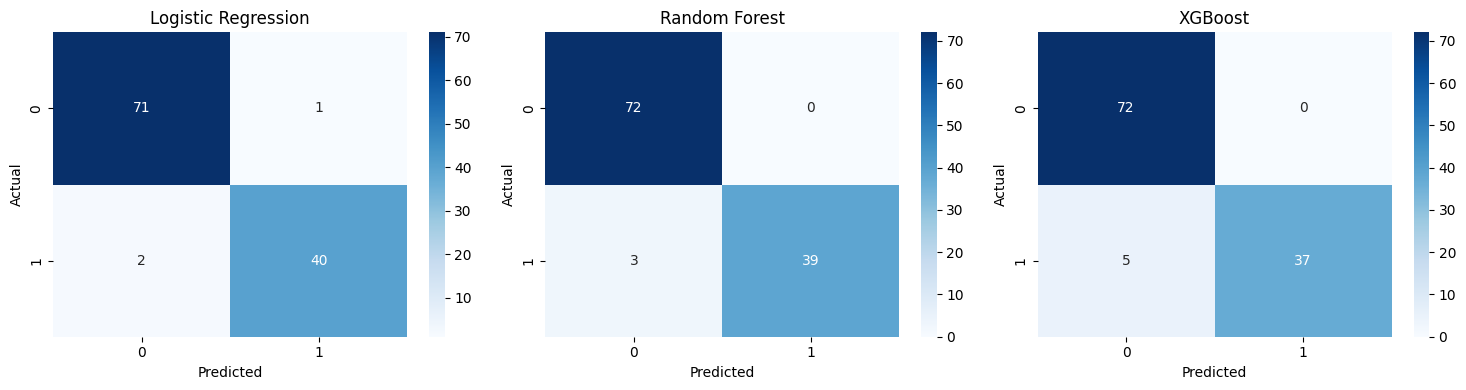

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
models_to_plot = [
    ("Logistic Regression", lr_model.predict(X_test_scaled)),
    ("Random Forest", rf_model.predict(X_test)),
    ("XGBoost", xgb_model.predict(X_test)),
]
for ax, (name, y_pred) in zip(axes, models_to_plot):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

## Prediction & Evaluation

Predictions are made using the `predict()` method of the trained model.

Classification models are evaluated using metrics like:
- **Accuracy**: Proportion of correct predictions
- **Precision**: Proportion of positive identifications that were correct
- **Recall**: Proportion of actual positives that were identified correctly
- **F1-score**: Harmonic mean of precision and recall

In [12]:
model_dictionary = {
    "LogisticRegression": (lr_model, X_test_scaled),
    "RandomForest": (rf_model, X_test),
    "XGBoost": (xgb_model, X_test),
    "SVC": (svc_model, X_test_scaled),
    "DecisionTree": (dt_model, X_test),
}

results = {}
for name, (model, X_te) in model_dictionary.items():
    y_pred = model.predict(X_te)
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
    }

results_df = pd.DataFrame(results).T
print("Model Performance Comparison:")
print(results_df.round(4))

Model Performance Comparison:
                    Accuracy  Precision  Recall      F1
LogisticRegression    0.9737     0.9756  0.9524  0.9639
RandomForest          0.9737     1.0000  0.9286  0.9630
XGBoost               0.9561     1.0000  0.8810  0.9367
SVC                   0.9561     0.9744  0.9048  0.9383
DecisionTree          0.9035     0.9189  0.8095  0.8608


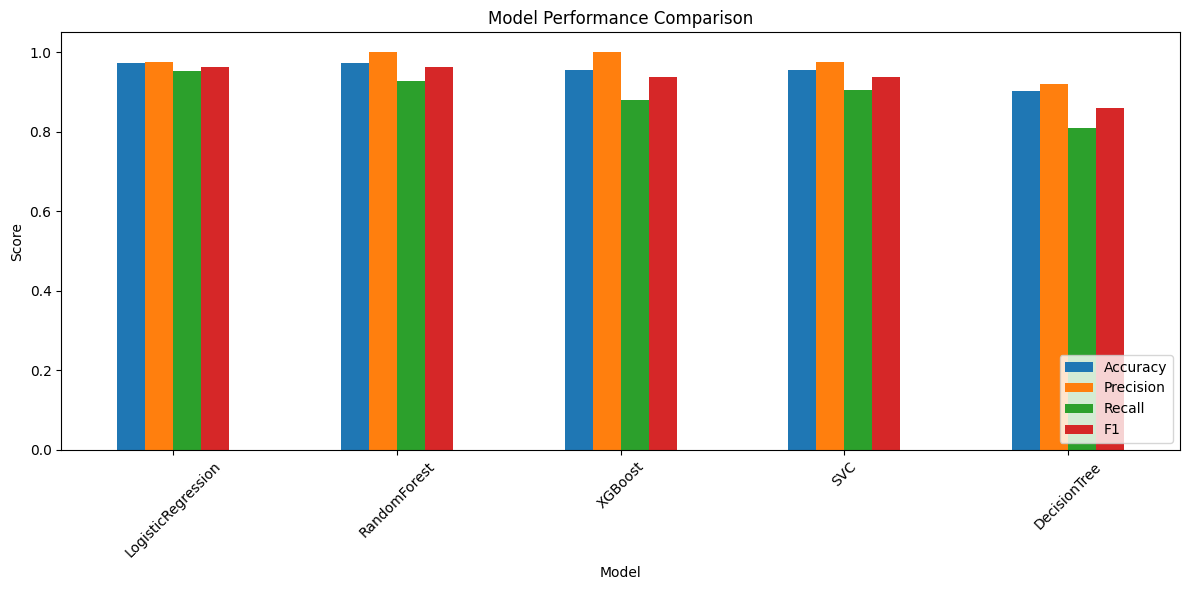

In [13]:
results_df.plot(kind="bar", figsize=(12, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

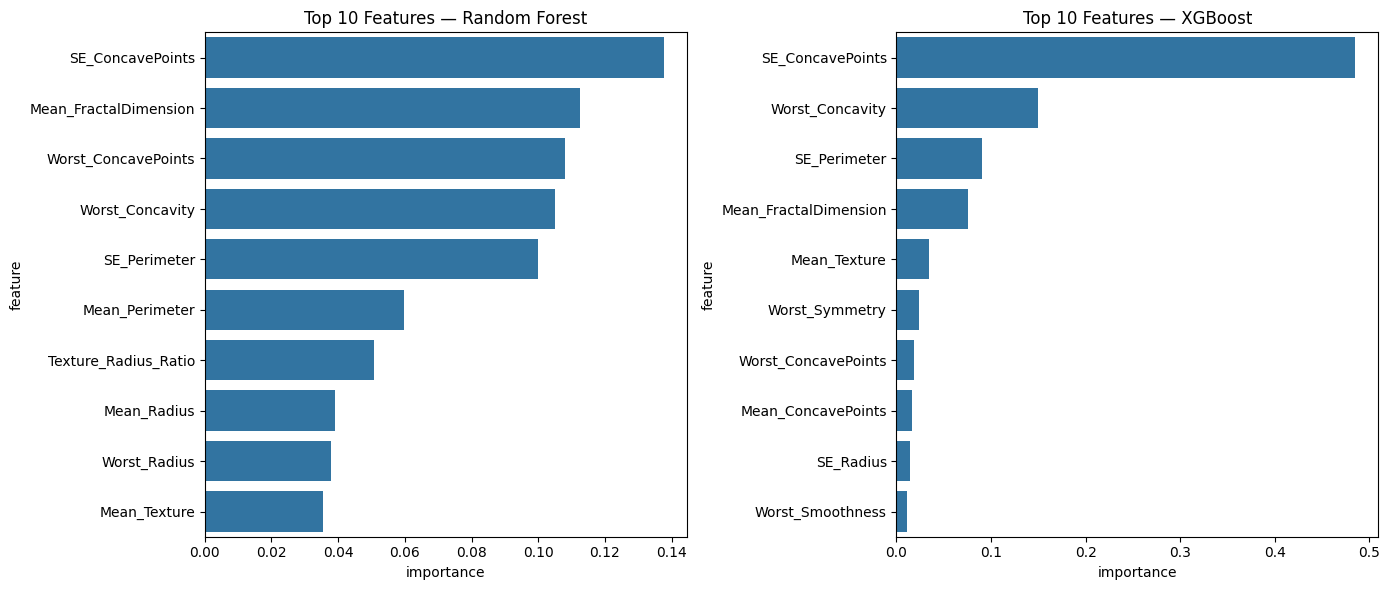

In [14]:
feature_names = X.columns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, model, title in [
    (axes[0], rf_model, "Random Forest"),
    (axes[1], xgb_model, "XGBoost"),
]:
    importances = pd.DataFrame({
        "feature": feature_names,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False).head(10)
    sns.barplot(x="importance", y="feature", data=importances, ax=ax)
    ax.set_title(f"Top 10 Features — {title}")
plt.tight_layout()
plt.show()

## Model Interpretability with SHAP

SHAP (SHapley Additive exPlanations) is a game-theoretic approach to explain the output of machine learning models. It provides consistent and locally accurate feature importance values by computing Shapley values from cooperative game theory.

Unlike traditional feature importance (which tells you which features matter globally), SHAP explains individual predictions — showing how each feature contributed to pushing a prediction away from the average.

### SHAP vs Traditional Feature Importance

While the bar charts above show global feature importance (average reduction in impurity across all trees), SHAP values provide:

- **Local explanations**: How each feature affects individual predictions
- **Consistency**: If a model changes so a feature matters more, its SHAP value never decreases
- **Directionality**: SHAP shows whether a feature pushes predictions up (toward malignant) or down (toward benign)

In [40]:
import shap
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

sv = shap_values[1] if isinstance(shap_values, list) else shap_values[:,:,0]
print(f"SHAP values shape: {sv.shape}")

SHAP values shape: (114, 34)


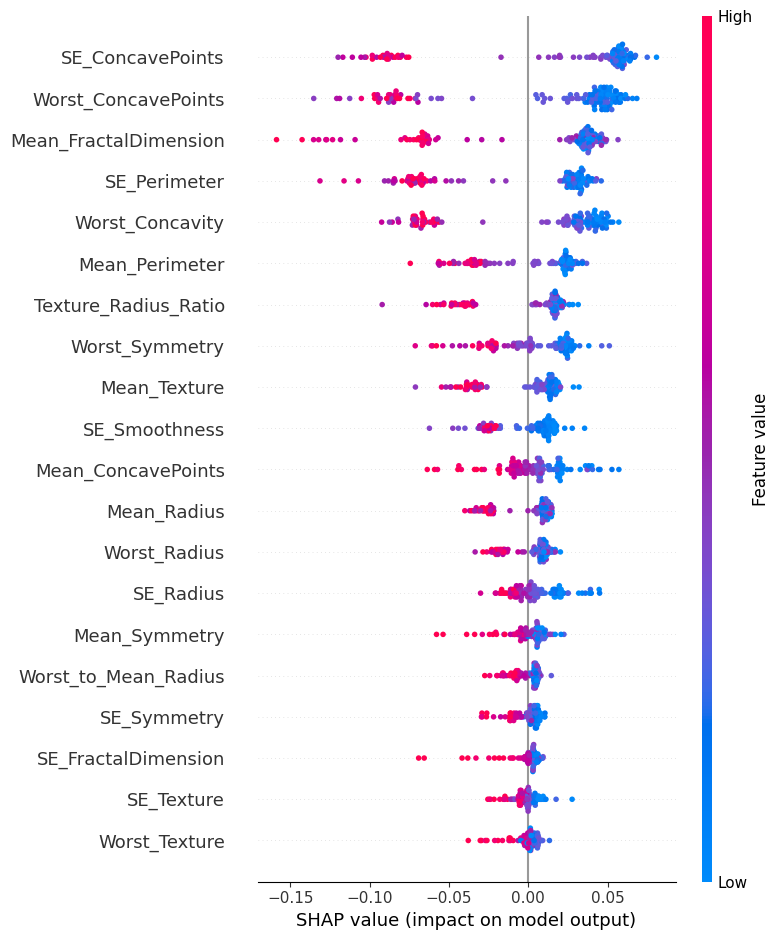

In [41]:
shap.summary_plot(sv, X_test, feature_names=feature_names)

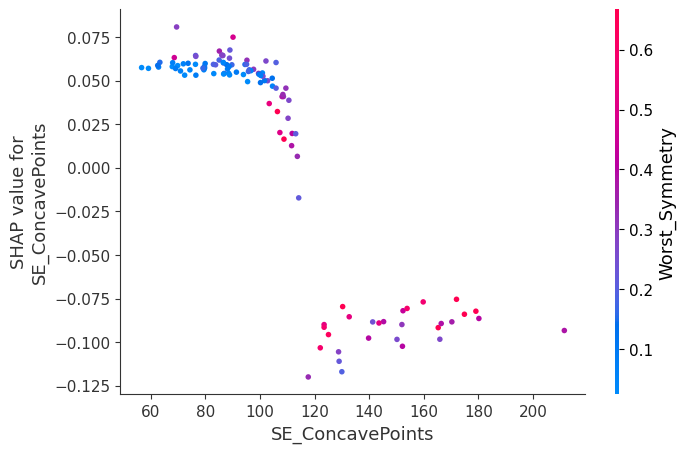

In [ ]:
# --- c) Individual feature dependence
feature = 'SE_ConcavePoints'

shap.dependence_plot(feature, sv, X_test, feature_names=feature_names)

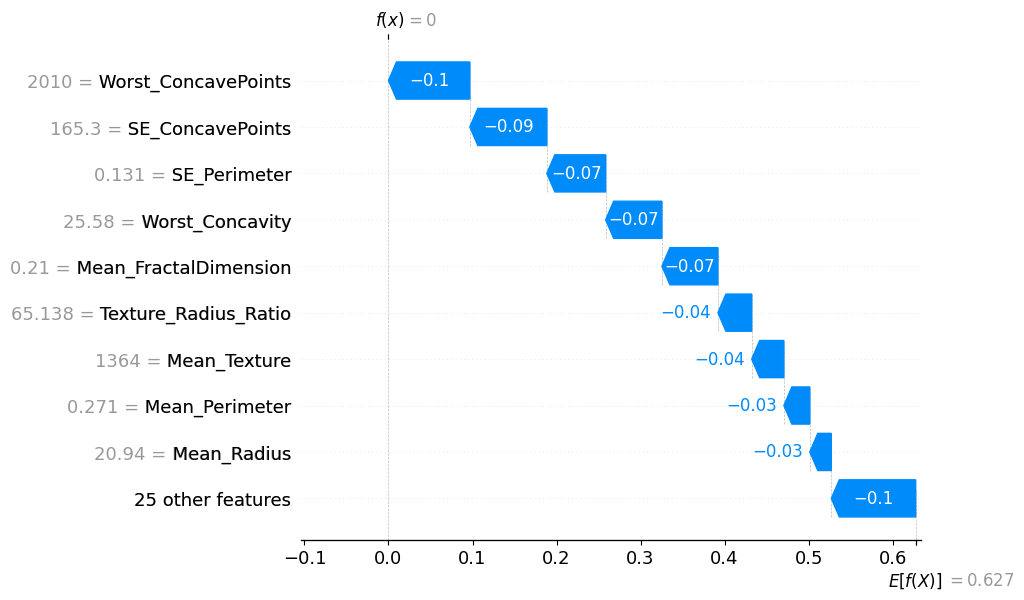

In [84]:
y_pred_rf = rf_model.predict(X_test)
malignant_idx = np.where(y_pred_rf == 1)[0][0]

shap.plots.waterfall(explainer(X_test)[:,:,0][malignant_idx])

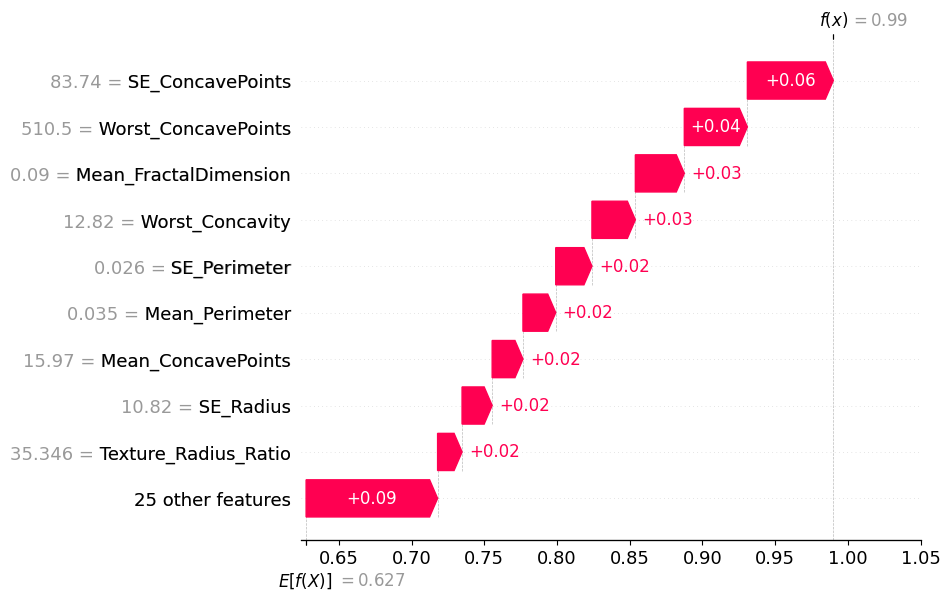

In [86]:
benign_idx = np.where(y_pred_rf == 0)[0][0]

shap.plots.waterfall(explainer(X_test)[:,:,0][benign_idx])

## MLflow Tracking

MLflow is an open-source platform for managing the machine learning lifecycle, including experimentation, reproducibility, and deployment. We will use MLflow to log our model training experiments, including parameters, metrics, and artifacts.

### Logging Experiments

- Setting up MLflow tracking

**Runs**: Each time you train a model, you can log it as a run in MLflow. You can log parameters (e.g., model hyperparameters), metrics (e.g., accuracy, F1), and artifacts (e.g., trained model files).

**Experiments**: Experiments are a collection of runs. You can organize your runs into experiments to keep track of different model training sessions.

```python
import mlflow
mlflow.set_experiment("Breast Cancer Classification")
with mlflow.start_run(run_name="Random Forest"):
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("f1", f1)
    mlflow.sklearn.log_model(rf_model, "random_forest_model")
```

In [ ]:
import mlflow

try:
    mlflow.set_experiment("Breast Cancer Classification")
    for name, (model, X_te) in model_dictionary.items():
        with mlflow.start_run(run_name=name):
            y_pred = model.predict(X_te)
            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)
            mlflow.log_param("model_type", name)
            mlflow.log_metric("accuracy", acc)
            mlflow.log_metric("f1", f1)
            mlflow.sklearn.log_model(model, f"{name}_model")
    print("MLflow logging complete")
except Exception as e:
    print(f"MLflow logging skipped ({e})")

### Model Saving & Loading

After training, we can save our models using `joblib` or `pickle` for later use. This allows us to load the trained model without retraining it, which is especially useful for deployment.

joblib is often preferred for saving scikit-learn models because it is more efficient at handling large numpy arrays, which are common in machine learning models.

pickle can also be used, but it may not be as efficient for large models.

In [ ]:
best_model_name = results_df["F1"].idxmax()
best_model = model_dictionary[best_model_name][0]

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODELS_DIR / f"{best_model_name}.pkl"
joblib.dump(best_model, model_path)
print(f"Best model ({best_model_name}) saved to {model_path}")
print(f"Best F1 score: {results_df.loc[best_model_name, 'F1']:.4f}")

In [ ]:
loaded_model = joblib.load(model_path)
X_te_best = model_dictionary[best_model_name][1]
y_pred_loaded = loaded_model.predict(X_te_best)
y_pred_original = best_model.predict(X_te_best)

assert (y_pred_loaded == y_pred_original).all(), "Predictions don't match!"
print(f"Loaded model produces identical predictions (all {len(y_pred_loaded)} match) ✓")

## Data Saving

Large datasets can be saved in efficient formats like Parquet or HDF5, which support fast read/write operations and compression. This is especially useful when working with large datasets that may not fit into memory.

**Parquet** is a columnar storage file format that is optimized for performance and storage efficiency.

Saving and loading data in parquet format is made easy with pandas using the `.to_parquet()` and `.read_parquet()` methods.

In [ ]:
results_df.to_csv(PROCESSED_DIR / "evaluation_results.csv", index=True)
print("Evaluation results saved to data/processed/evaluation_results.csv")

### Exercises

1. **Add new model**: Try training a KNeighborsClassifier and compare performance.
2. **Feature importance**: Use RandomForestClassifier's feature_importances_ to identify key features.
3. **Confusion matrix**: Plot confusion matrices for each model to visualize misclassifications.
4. **Cross-validation**: Use cross_val_score to get more robust performance estimates.
5. **What's missing?**: Can you think of something that will be important to apply this model in the real world?